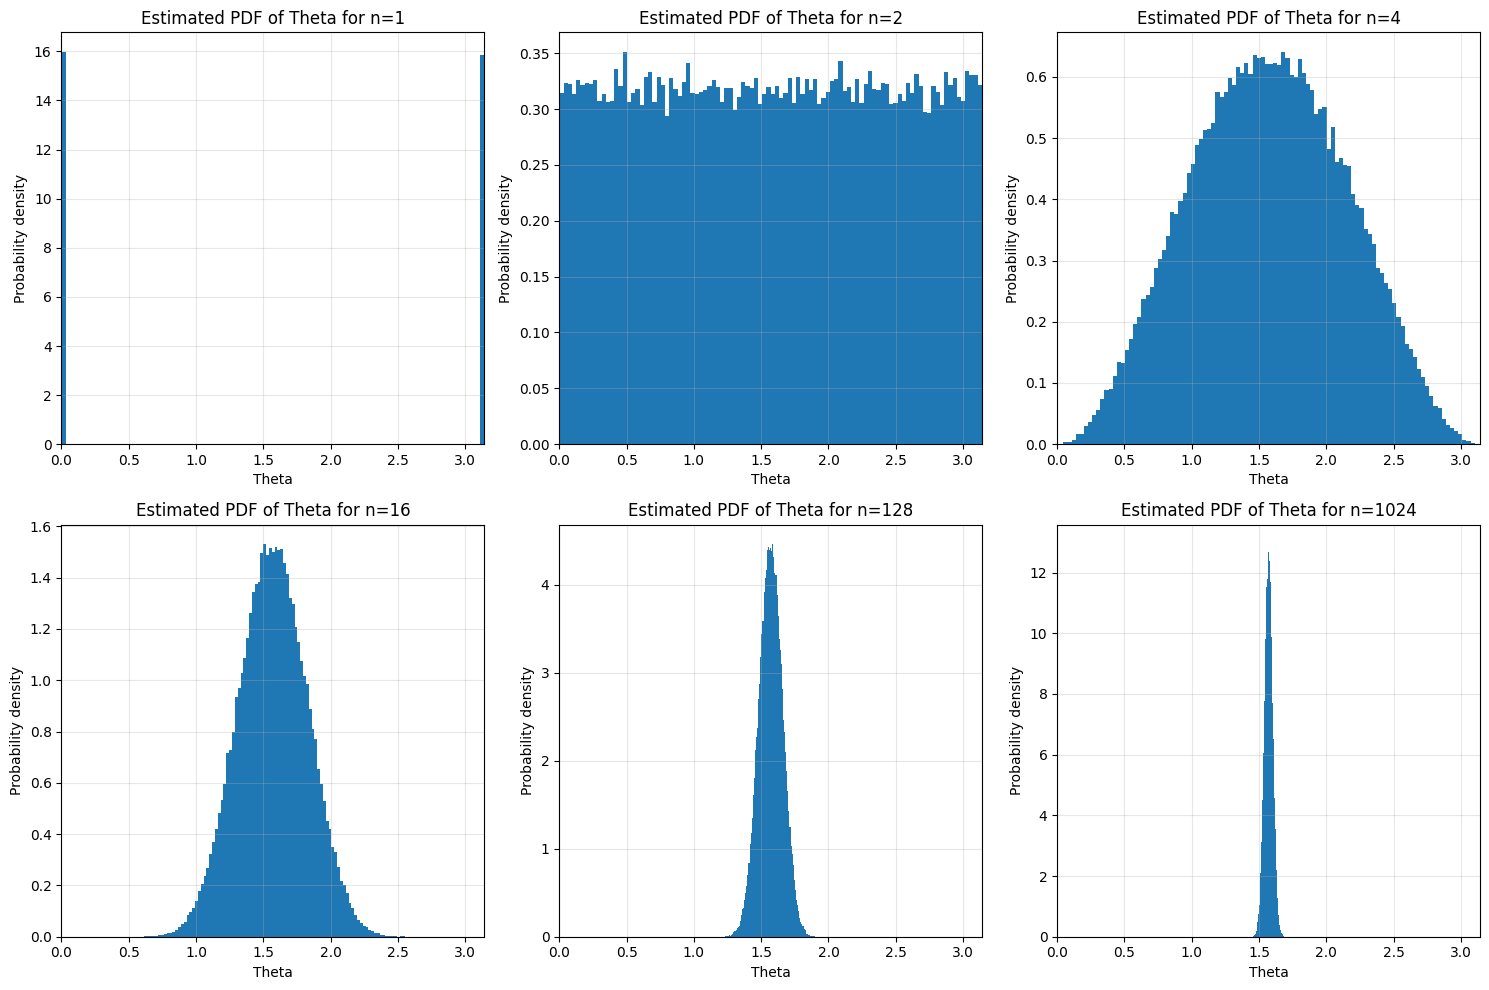

In [3]:
import os
os.environ["CUDA_VISIBLE_DEVICES"]="1"

import torch
import matplotlib.pyplot as plt

ns = [1, 2, 4, 16, 128, 1024]
torch.random.manual_seed(42)
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, n in enumerate(ns):
    ax = axes[i]
    x = torch.randn(size=(100000, n), device="cuda")
    y = torch.randn(size=(100000, n), device="cuda")
    prod = (x * y).sum(dim=1) / (torch.norm(x, p=2, dim=1) * torch.norm(y, p=2, dim=1))
    prod = prod.clamp(-1., 1.)
    theta = torch.acos(prod)

    counts, bin_edges = torch.histogram(theta.to("cpu"), 100, density=True)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    ax.bar(bin_centers.numpy(), counts.numpy(), width=bin_edges[1]-bin_edges[0])
    ax.set_xlabel("Theta")
    ax.set_xlim(0, torch.math.pi)
    ax.set_ylabel("Probability density")
    ax.set_title(f"Estimated PDF of Theta for n={n}")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"]="1"

import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset
import numpy as np

torch.manual_seed(42)
np.random.seed(42)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_set_full = torchvision.datasets.FashionMNIST(
    root="./data", train=True, download=True, transform=transform
)
test_set_full = torchvision.datasets.FashionMNIST(
    root="./data", train=False, download=True, transform=transform
)
train_indices = np.random.choice(len(train_set_full), 20000, replace=False)
test_indices = np.random.choice(len(test_set_full), 5000, replace=False)
train_set = Subset(train_set_full, train_indices)
test_set = Subset(test_set_full, test_indices)
train_loader = DataLoader(train_set, batch_size=64, shuffle=True)
test_loader = DataLoader(test_set, batch_size=64, shuffle=False)

In [2]:
from torch import nn

class PatchEmbed(nn.Module):
    def __init__(
        self,
        in_channels,
        out_channels,
        patch_size=4,
    ):
        super().__init__()
        self.patch_size = patch_size
        self.proj = nn.Conv2d(
            in_channels,
            out_channels,
            patch_size,
            patch_size
        )

    def forward(self, x):
        x = self.proj(x)
        x = x.flatten(2)
        x = x.transpose(1, 2)   # [bsz, num_seq, out_channels]

        return x



class Attention(nn.Module):
    def __init__(
        self,
        hidden_dim,
        num_attn_heads,
        attn_drop=0.,
        proj_drop=0.
    ):
        super().__init__()
        self.num_attn_heads = num_attn_heads
        self.head_dim = hidden_dim // num_attn_heads
        
        self.qkv = nn.Linear(hidden_dim, hidden_dim * 3)
        self.attn_drop = nn.Dropout(attn_drop)
        self.proj = nn.Linear(hidden_dim, hidden_dim)
        self.proj_drop = nn.Dropout(proj_drop)
    
    def forward(self, x):
        B, N, D = x.shape
        qkv = self.qkv(x).reshape(B, N, 3, self.num_attn_heads, self.head_dim)
        # [B, N, 3, num_heads, head_dim] -> [3, B, num_heads, N, head_dim]
        qkv = qkv.permute(2, 0, 3, 1, 4)
        q, k, v = qkv.unbind(0)

        attn = (q @ k.transpose(-2, -1)) * (self.head_dim ** -0.5)
        attn = attn.softmax(dim=-1)
        attn = self.attn_drop(attn)

        out = attn @ v
        out = out.transpose(1, 2).reshape(B, N, D)
        out = self.proj(out)
        out = self.proj_drop(out)

        return out

class Mlp(nn.Module):
    def __init__(
        self,
        in_features,
        out_features,
        hidden_dim,
        dropout=0.
    ):
        super().__init__()
        self.fc1 = nn.Linear(in_features, hidden_dim)
        self.act = nn.GELU()
        self.drop = nn.Dropout(dropout)
        self.fc2 = nn.Linear(hidden_dim, out_features)

    
    def forward(self, x):
        x = self.fc1(x)
        x = self.act(x)
        x = self.drop(x)
        x = self.fc2(x)
        x = self.drop(x)

        return x

class ViTBlock(nn.Module):
    def __init__(
        self,
        hidden_dim,
        num_attn_heads,
        mlp_ratio=4,
        attn_drop=0.,
        proj_drop=0.,
        drop=0.
    ):
        super().__init__()
        self.norm1 = nn.LayerNorm(hidden_dim)
        self.attn = Attention(hidden_dim, num_attn_heads, attn_drop, proj_drop)
        self.norm2 = nn.LayerNorm(hidden_dim)
        self.mlp = Mlp(hidden_dim, hidden_dim, int(hidden_dim * mlp_ratio), dropout=drop)

    def forward(self, x):
        x = x + self.attn(self.norm1(x))
        x = x + self.mlp(self.norm2(x))

        return x

class ViT(nn.Module):
    def __init__(
        self,
        img_size,
        hidden_dim,
        num_attn_heads,
        num_blocks,
        out_features,
        in_channels=3,
        patch_size=4,
        mlp_ratio=4,
        attn_drop=0.,
        proj_drop=0.,
        drop=0.
    ):
        super().__init__()
        self.img_size = img_size
        self.hidden_dim = hidden_dim
        self.num_blocks = num_blocks
        self.num_patch = (img_size // patch_size) ** 2

        self.patch_embed = PatchEmbed(in_channels, hidden_dim, patch_size=patch_size)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, hidden_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, self.num_patch+1, hidden_dim))
        self.blocks = nn.Sequential(*[
            ViTBlock(hidden_dim, num_attn_heads, mlp_ratio, attn_drop, proj_drop, drop) for _ in range(num_blocks)
        ])

        self.norm = nn.LayerNorm(hidden_dim)
        self.final_layer = nn.Linear(hidden_dim, out_features)

        self._init_weight()

    def _init_weight(self):
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.trunc_normal_(m.weight, std=0.02)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.LayerNorm):
                nn.init.constant_(m.weight, 1.0)
                nn.init.constant_(m.bias, 0)

    def _pos_embed(self, x):
        return x + self.pos_embed

    def forward(self, x):
        x = self.patch_embed(x)
        x = torch.cat((self.cls_token.expand(x.shape[0], -1, -1), x), dim=1)
        x = self._pos_embed(x)
        for block in self.blocks:
            x = block(x)
        x = self.norm(x)
        x = x[:, 0]     # cls token
        x = self.final_layer(x)

        return x

In [9]:
from torch.optim import Adam

def train(
    model,
    train_dataloader,
    test_dataloader,
    device,
    optimizer,
    criterion,
    epochs
):
    losses = []
    accs = []
    for _ in range(epochs):
        model.train()
        e_loss = 0.
        correct = 0
        for img, label in train_dataloader:
            bsz = img.size(0)
            optimizer.zero_grad()
            out = model(img.to(device))
            loss = criterion(out, label.to(device))
            loss.backward()
            optimizer.step()
            e_loss += loss.item() * bsz

        e_loss /= len(train_dataloader.dataset)

        model.eval()
        for img, label in test_dataloader:
            bsz = img.size(0)
            out = model(img.to(device))
            pred = out.argmax(dim=1)
            correct += pred.eq(label.to(device)).sum().item()

        acc = correct / len(test_dataloader.dataset)

        losses.append(e_loss)
        accs.append(acc)
        
    return losses, accs

model = ViT(img_size=28, hidden_dim=64, num_attn_heads=4, num_blocks=2, out_features=10, in_channels=1, patch_size=4)
device = "cuda"
model.to(device=device)

optimizer = Adam(model.parameters(), lr=0.001, betas=(0.9, 0.999))
criterion = nn.CrossEntropyLoss()

epochs = 10
losses, accs = train(model, train_loader, test_loader, device, optimizer, criterion, epochs)

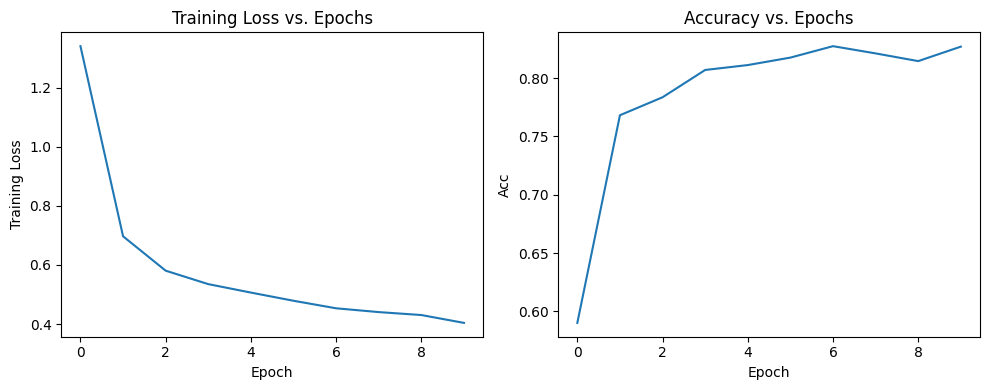

In [10]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
x = range(len(losses))
ax1.plot(x, losses)
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Training Loss")
ax1.set_title("Training Loss vs. Epochs")
ax2.plot(x, accs)
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Acc")
ax2.set_title("Accuracy vs. Epochs")
plt.tight_layout()
plt.show()

In [5]:
class CNN(nn.Module):
    def __init__(
        self,
        in_channels,
        out_channels,
        hidden_dim,
        kernel_size=1,
        stride=1,
        padding=0,
    ):
        super().__init__()
        self.conv1 = nn.Conv2d(
            in_channels=in_channels,
            out_channels=hidden_dim,
            kernel_size=kernel_size,
            stride=stride,
            padding=padding
        )
        # self.norm1 = nn.BatchNorm2d(num_features=hidden_dim)
        self.act = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv2 = nn.Conv2d(
            in_channels=hidden_dim,
            out_channels=out_channels,
            kernel_size=kernel_size,
            stride=stride,
            padding=padding
        )
        # self.norm2 = nn.BatchNorm2d(num_features=out_channels)
        
        # 28 x 28 -> 14 x 14 -> 7 x 7
        # hard code here, add assertion
        # self.global_pool = nn.AdaptiveMaxPool2d is a better choice 
        assert (kernel_size - 1) // 2 == padding
        self.fc = nn.Linear(in_features=out_channels * 49, out_features=10)
    
    def forward(self, x):
        x = self.pool(self.act(self.conv1(x)))
        x = self.pool(self.act(self.conv2(x)))
        x = torch.flatten(x, 1)
        x = self.fc(x)

        return x
    
cnn_model = CNN(in_channels=1, out_channels=64, hidden_dim=32, kernel_size=3, stride=1, padding=1)
cnn_model.to(device)
cnn_optimizer = Adam(cnn_model.parameters(), lr=0.001, betas=(0.9, 0.999))
cnn_losses, cnn_accs = train(cnn_model, train_loader, test_loader, device, cnn_optimizer, criterion, epochs)

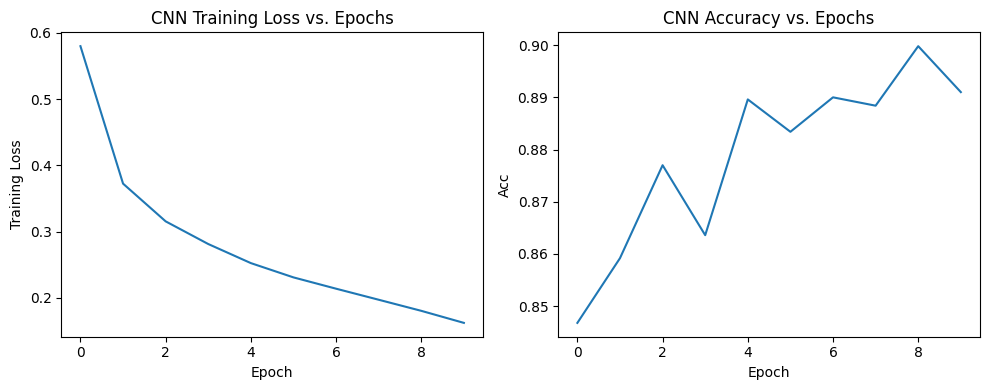

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
x = range(len(cnn_losses))
ax1.plot(x, cnn_losses)
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Training Loss")
ax1.set_title("CNN Training Loss vs. Epochs")
ax2.plot(x, cnn_accs)
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Acc")
ax2.set_title("CNN Accuracy vs. Epochs")
plt.tight_layout()
plt.show()

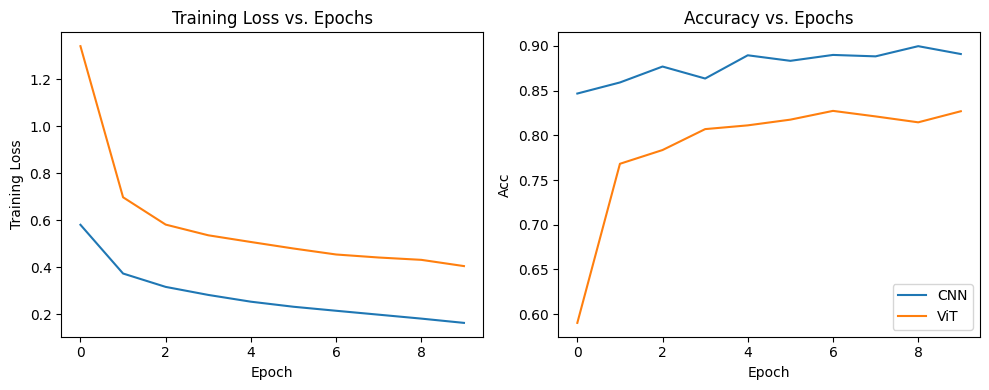

In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
x = range(len(cnn_losses))
ax1.plot(x, cnn_losses, label="CNN")
ax1.plot(x, losses, label="ViT")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Training Loss")
ax1.set_title("Training Loss vs. Epochs")
ax2.plot(x, cnn_accs, label="CNN")
ax2.plot(x, accs, label="ViT")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Acc")
ax2.set_title("Accuracy vs. Epochs")
plt.legend()
plt.tight_layout()
plt.show()